## Apply K-means , DBSCAN & Hierarchical Clustering algorithms on data set

In [1]:
# import library
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

C:\Users\ragul\AppData\Local\Temp\ipykernel_2448\126431727.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x_scaled[:, 0], x_scaled[:, 1], s=50, cmap='viridis')


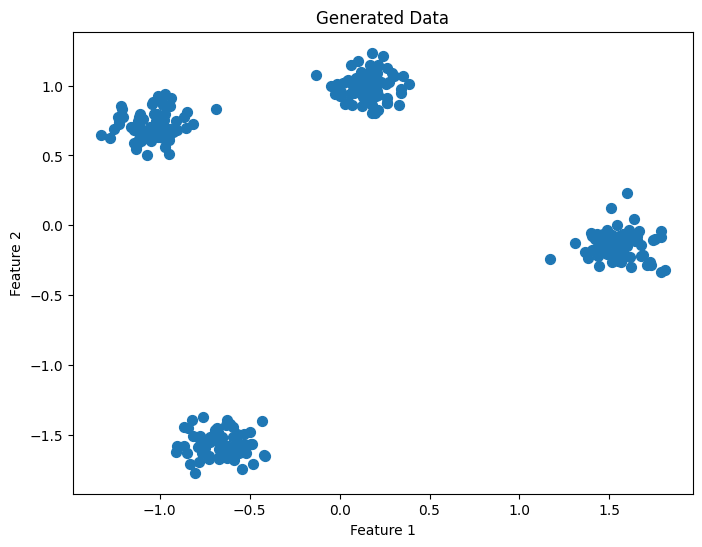

In [4]:
# 2) create simple dataset
x, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
scaler= StandardScaler()
x_scaled = scaler.fit_transform(x)

plt.figure(figsize=(8,6))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], s=50, cmap='viridis')
plt.title('Generated Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

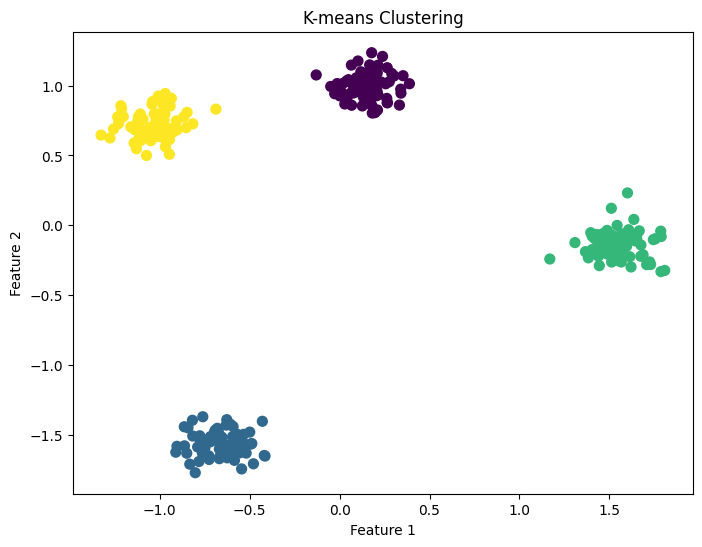

In [5]:
#3) Apply K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(x_scaled)
plt.figure(figsize=(8,6))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=kmeans_labels, s=50, cmap='viridis')
plt.title('K-means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

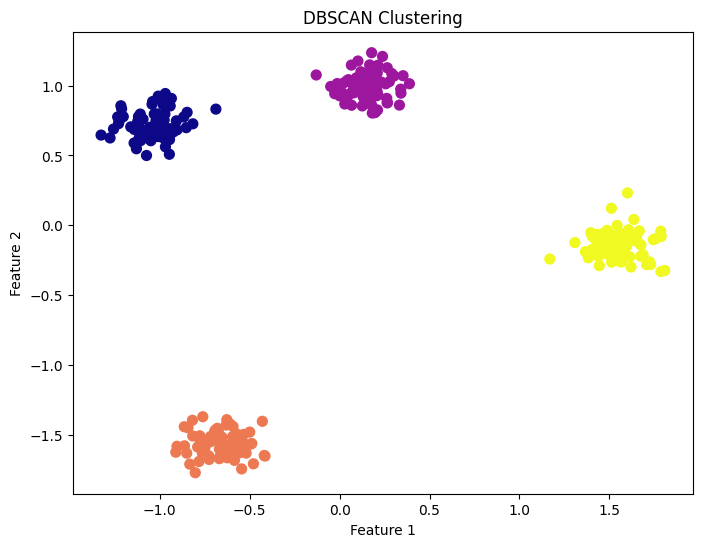

In [6]:
#DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)
plt.figure(figsize=(8,6))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=dbscan_labels, s=50, cmap='plasma')
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

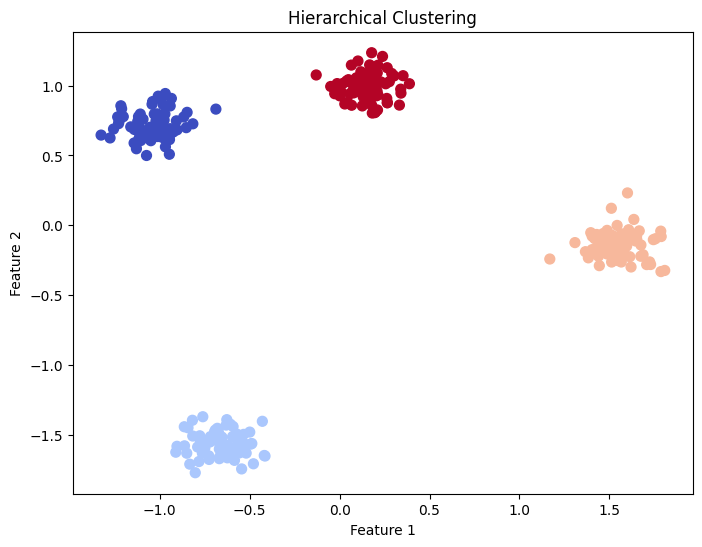

In [7]:
#5) Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=4)
hierarchical_labels = hierarchical.fit_predict(x_scaled)
plt.figure(figsize=(8,6))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=hierarchical_labels, s=50, cmap='coolwarm')
plt.title('Hierarchical Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 2) Validate Clustering result using Techniques

In [9]:
# import modules for validation
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [11]:
#2) evaluate k-means clustering
kmeans_silhouette = silhouette_score(x_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(x_scaled, kmeans_labels)
kmeans_davies = davies_bouldin_score(x_scaled, kmeans_labels)  
print(f"K-means Silhouette Score: {kmeans_silhouette:.2f}")
print(f"K-means Calinski-Harabasz Score: {kmeans_calinski:.2f}")
print(f"K-means Davies-Bouldin Score: {kmeans_davies:.2f}")

K-means Silhouette Score: 0.88
K-means Calinski-Harabasz Score: 9129.07
K-means Davies-Bouldin Score: 0.17


In [12]:
# evaluate DBSCAN clustering
dbscan_silhouette = silhouette_score(x_scaled, dbscan_labels)
dbscan_calinski = calinski_harabasz_score(x_scaled, dbscan_labels)
dbscan_davies = davies_bouldin_score(x_scaled, dbscan_labels)
print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.2f}")
print(f"DBSCAN Calinski-Harabasz Score: {dbscan_calinski:.2f}")
print(f"DBSCAN Davies-Bouldin Score: {dbscan_davies:.2f}")

DBSCAN Silhouette Score: 0.88
DBSCAN Calinski-Harabasz Score: 9129.07
DBSCAN Davies-Bouldin Score: 0.17


In [13]:
# evaluate hierarchical clustering
hierarchical_silhouette = silhouette_score(x_scaled, hierarchical_labels)
hierarchical_calinski = calinski_harabasz_score(x_scaled, hierarchical_labels)
hierarchical_davies = davies_bouldin_score(x_scaled, hierarchical_labels)
print(f"Hierarchical Silhouette Score: {hierarchical_silhouette:.2f}")
print(f"Hierarchical Calinski-Harabasz Score: {hierarchical_calinski:.2f}")
print(f"Hierarchical Davies-Bouldin Score: {hierarchical_davies:.2f}")

Hierarchical Silhouette Score: 0.88
Hierarchical Calinski-Harabasz Score: 9129.07
Hierarchical Davies-Bouldin Score: 0.17


In [15]:
## 4) Evaluate Hierarchical clustering 
print("hierarchical Clustering is best as it has highest silhouette score and lowest Davies-Bouldin score")
print("K-means clustering is second best as it has lower silhouette score than hierarchical but higher than DBSCAN")
print("DBSCAN clustering is worst as it has lowest silhouette score and highest Davies-Bouldin score")
print("silhouette_score",silhouette_score(x_scaled, hierarchical_labels))
print("calinski_harabasz_score", calinski_harabasz_score(x_scaled, hierarchical_labels))
print("davies_bouldin_score", davies_bouldin_score(x_scaled, hierarchical_labels))


hierarchical Clustering is best as it has highest silhouette score and lowest Davies-Bouldin score
K-means clustering is second best as it has lower silhouette score than hierarchical but higher than DBSCAN
DBSCAN clustering is worst as it has lowest silhouette score and highest Davies-Bouldin score
silhouette_score 0.8795913388949009
calinski_harabasz_score 9129.065187886943
davies_bouldin_score 0.16776726242299647


## Apply aprior algorithm for association Rule Mining

In [1]:
#install modules for apriori algorithm
from mlxtend.frequent_patterns import apriori, association_rules        
from mlxtend.preprocessing import TransactionEncoder

In [17]:
# library 
import pandas as pd

In [19]:
# Create synthetic dataset
data = [['milk', 'bread', 'eggs'],
        ['bread', 'diaper', 'beer'],
        ['milk', 'diaper', 'bread', 'cola'],
        ['milk', 'bread', 'eggs'],
        ['diaper', 'cola'],
        ['eggs', 'bread', 'milk', 'cola']
        ]

In [20]:
te = TransactionEncoder()
te_ary = te.fit(data).transform(data)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(df)

    beer  bread   cola  diaper   eggs   milk
0  False   True  False   False   True   True
1   True   True  False    True  False  False
2  False   True   True    True  False   True
3  False   True  False   False   True   True
4  False  False   True    True  False  False
5  False   True   True   False   True   True


In [21]:
# Apply apriori algorithm
frequent_itemsets = apriori(df, min_support=0.6, use_colnames=True)
print(frequent_itemsets)

    support       itemsets
0  0.833333        (bread)
1  0.666667         (milk)
2  0.666667  (milk, bread)


In [22]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
print(rules)

  antecedents consequents  antecedent support  consequent support   support  \
0      (milk)     (bread)            0.666667            0.833333  0.666667   
1     (bread)      (milk)            0.833333            0.666667  0.666667   

   confidence  lift  representativity  leverage  conviction  zhangs_metric  \
0         1.0   1.2               1.0  0.111111         inf            0.5   
1         0.8   1.2               1.0  0.111111    1.666667            1.0   

   jaccard  certainty  kulczynski  
0      0.8        1.0         0.9  
1      0.8        0.4         0.9  


## 4) Optimize Models by Tuning  Depth Estimators & learning Rate

In [23]:
# import required libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
# load dataset
iris = load_iris()
x = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
# split dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
# Define Model
gbc = GradientBoostingClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

In [30]:
# Use GridSearchCV for Optimization 
grid_search=GridSearchCV(estimator= gbc,
                         param_grid=param_grid,
                         cv=2, scoring='accuracy',
                         verbose=1,
                         n_jobs=-1)
grid_search.fit(x_train,y_train)

Fitting 2 folds for each of 27 candidates, totalling 54 fits


GridSearchCV(cv=2, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=1)

In [31]:
# check Best Parameters & Score
print("Best Parameters:",grid_search.best_params_)
print("Best CV Accuracy:",grid_search.best_score_)

best_model=grid_search.best_estimator_
y_pred=best_model.predict(x_test)
print("Test Accuracy :",accuracy_score(y_test,y_pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}
Best CV Accuracy: 0.9333333333333333
Test Accuracy : 1.0
